In [1]:
# Program developed by Chidroop M J, B.Tech.,AIML.

In [5]:
from google.colab import drive
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

project_path = '/content/drive/MyDrive/MLP_DryBean_Project'
os.makedirs(project_path, exist_ok=True)
print(f"Project directory: {project_path}")

print("\nDownloading dataset...")
!wget -q --no-check-certificate -O /content/DryBeanDataset.zip https://archive.ics.uci.edu/static/public/602/dry+bean+dataset.zip

print("Extracting files...")
with zipfile.ZipFile('/content/DryBeanDataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/DryBeanDataset')

import glob
excel_files = glob.glob('/content/DryBeanDataset/**/*.xlsx', recursive=True)

if excel_files:
    !cp "{excel_files[0]}" {project_path}/
    print(f"Dataset saved to: {project_path}/{os.path.basename(excel_files[0])}")
else:
    csv_files = glob.glob('/content/DryBeanDataset/**/*.csv', recursive=True)
    if csv_files:
        !cp "{csv_files[0]}" {project_path}/
        print(f"Dataset saved to: {project_path}/{os.path.basename(csv_files[0])}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/MLP_DryBean_Project

Extracting files...
Dataset saved to: /content/drive/MyDrive/MLP_DryBean_Project/Dry_Bean_Dataset.xlsx


In [6]:
import glob

file_pattern = f'{project_path}/*.xlsx'
excel_files = glob.glob(file_pattern)

if not excel_files:
    file_pattern = f'{project_path}/*.csv'
    excel_files = glob.glob(file_pattern)

if excel_files:
    file_path = excel_files[0]
    print(f"Loading dataset from: {file_path}")
    data = pd.read_excel(file_path) if file_path.endswith('.xlsx') else pd.read_csv(file_path)

    print("\n" + "="*70)
    print("DRY BEAN DATASET - EXPLORATORY ANALYSIS")
    print("="*70)

    print(f"\nDataset Shape: {data.shape[0]} samples, {data.shape[1]} features")
    print(f"\nFeatures: {data.columns.tolist()}")
    print(f"\nClass Distribution:")
    class_counts = data['Class'].value_counts()
    for cls, count in class_counts.items():
        pct = (count / len(data)) * 100
        print(f"  {cls}: {count:5d} samples ({pct:5.2f}%)")

    print(f"\nStatistical Summary:")
    print(data.describe().round(2))
else:
    print("No dataset file found. Trying alternative download...")
    !wget -O {project_path}/Dry_Bean_Dataset.xlsx https://github.com/mkoklu/DryBeanDataset/blob/main/Dry_Bean_Dataset.xlsx?raw=true
    data = pd.read_excel(f'{project_path}/Dry_Bean_Dataset.xlsx')
    print("Dataset loaded from GitHub mirror.")

Loading dataset from: /content/drive/MyDrive/MLP_DryBean_Project/Dry_Bean_Dataset.xlsx

DRY BEAN DATASET - EXPLORATORY ANALYSIS

Dataset Shape: 13611 samples, 17 features

Features: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']

Class Distribution:
  DERMASON:  3546 samples (26.05%)
  SIRA:  2636 samples (19.37%)
  SEKER:  2027 samples (14.89%)
  HOROZ:  1928 samples (14.17%)
  CALI:  1630 samples (11.98%)
  BARBUNYA:  1322 samples ( 9.71%)
  BOMBAY:   522 samples ( 3.84%)

Statistical Summary:
            Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
count   13611.00   13611.00         13611.00         13611.00      13611.00   
mean    53048.28     855.28           320.14           202.27          1.58   
std     29324.10     214.29            85.69            44.97  

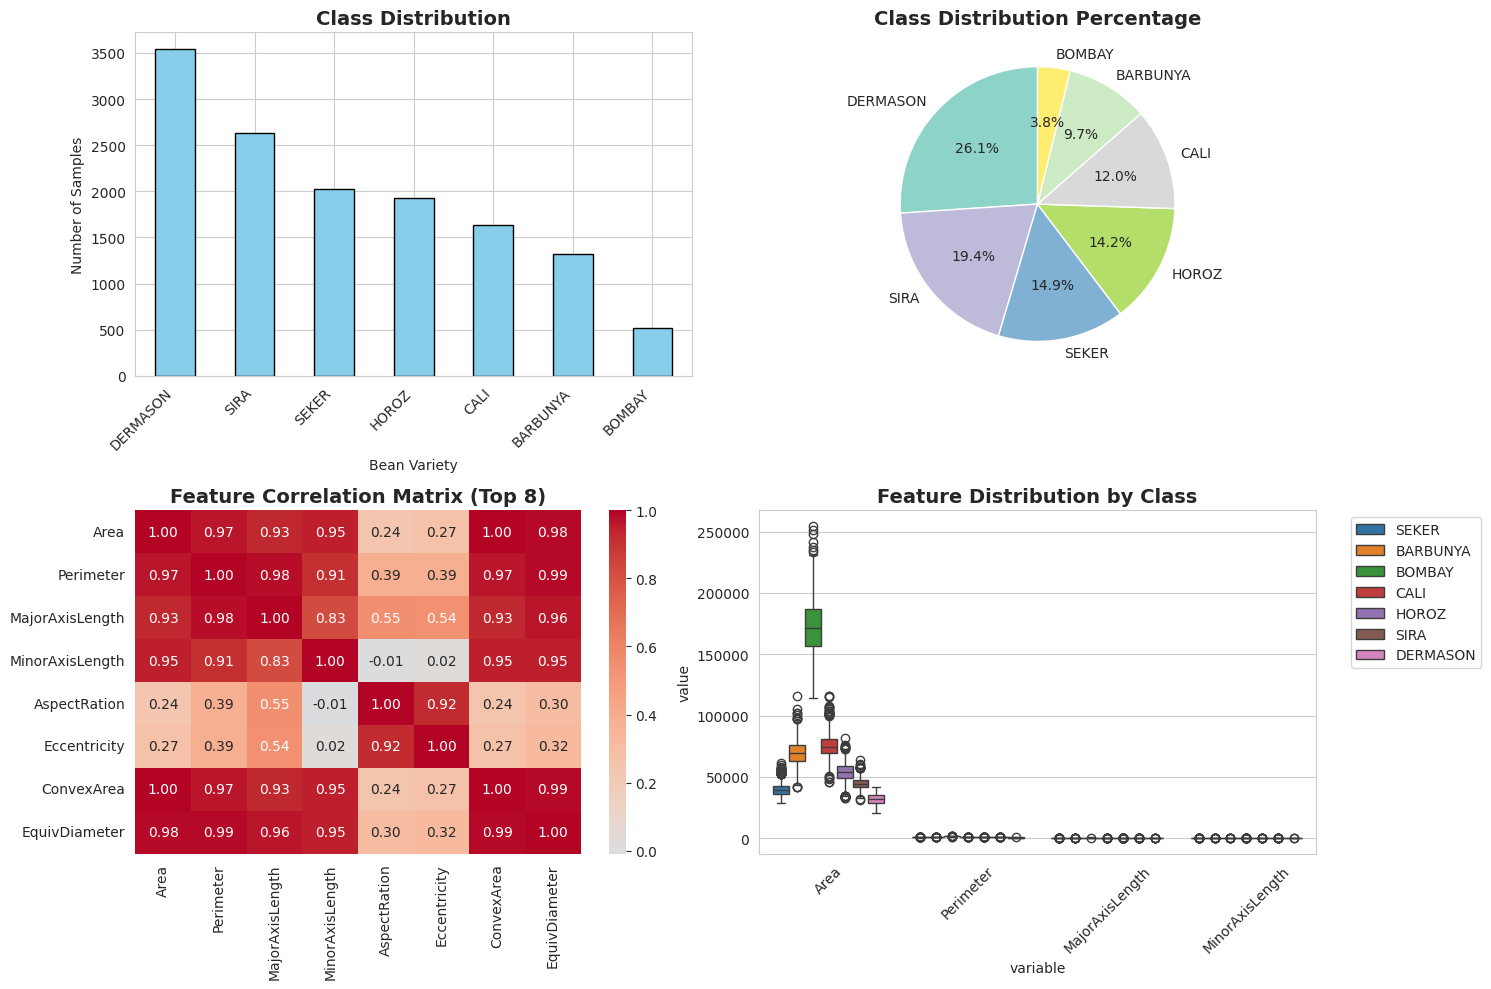

In [7]:
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
class_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Bean Variety')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')

plt.subplot(2, 2, 2)
plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
        startangle=90, colors=plt.cm.Set3(np.linspace(0, 1, 7)))
plt.title('Class Distribution Percentage', fontsize=14, fontweight='bold')

plt.subplot(2, 2, 3)
features = data.drop('Class', axis=1).columns[:8]
corr_matrix = data[features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', cbar=True)
plt.title('Feature Correlation Matrix (Top 8)', fontsize=14, fontweight='bold')

plt.subplot(2, 2, 4)
feature_columns = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength']
data_box = data[feature_columns + ['Class']]
data_melted = data_box.melt(id_vars=['Class'], value_vars=feature_columns)
sns.boxplot(data=data_melted, x='variable', y='value', hue='Class')
plt.title('Feature Distribution by Class', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [8]:
print("\n" + "="*70)
print("DATA PREPROCESSING")
print("="*70)

X = data.drop('Class', axis=1)
y = data['Class']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
print(f"\nEncoded Classes:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

print(f"\nTrain/Test Split:")
print(f"  Training: {X_train.shape[0]} samples")
print(f"  Testing: {X_test.shape[0]} samples")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

import joblib
joblib.dump(scaler, f'{project_path}/scaler.pkl')
joblib.dump(le, f'{project_path}/label_encoder.pkl')

print(f"\nPreprocessing complete. Scaler saved to Drive.")


DATA PREPROCESSING

Features shape: (13611, 16)
Target shape: (13611,)

Encoded Classes:
  0: BARBUNYA
  1: BOMBAY
  2: CALI
  3: DERMASON
  4: HOROZ
  5: SEKER
  6: SIRA

Train/Test Split:
  Training: 10888 samples
  Testing: 2723 samples

Preprocessing complete. Scaler saved to Drive.


In [9]:
class MLPFromScratch:
    def __init__(self, layer_sizes, learning_rate=0.01, epochs=1000,
                 activation='relu', output_activation='softmax'):
        self.layer_sizes = layer_sizes
        self.lr = learning_rate
        self.epochs = epochs
        self.activation = activation
        self.output_activation = output_activation
        self.weights = []
        self.biases = []
        self.loss_history = []

        np.random.seed(42)
        for i in range(len(layer_sizes) - 1):
            w = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * np.sqrt(2.0 / layer_sizes[i])
            b = np.zeros((1, layer_sizes[i+1]))
            self.weights.append(w)
            self.biases.append(b)

    def _activation_func(self, z, activation=None):
        if activation is None:
            activation = self.activation
        if activation == 'relu':
            return np.maximum(0, z)
        elif activation == 'tanh':
            return np.tanh(z)
        elif activation == 'sigmoid':
            return 1 / (1 + np.exp(-z))
        elif activation == 'softmax':
            exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
            return exp_z / np.sum(exp_z, axis=1, keepdims=True)
        elif activation == 'linear':
            return z

    def _activation_derivative(self, a):
        if self.activation == 'relu':
            return (a > 0).astype(float)
        elif self.activation == 'tanh':
            return 1 - a**2
        elif self.activation == 'sigmoid':
            return a * (1 - a)

    def forward(self, X):
        self.activations = [X]
        self.z_values = []

        for i in range(len(self.weights) - 1):
            z = np.dot(self.activations[-1], self.weights[i]) + self.biases[i]
            self.z_values.append(z)
            a = self._activation_func(z)
            self.activations.append(a)

        z = np.dot(self.activations[-1], self.weights[-1]) + self.biases[-1]
        self.z_values.append(z)
        a = self._activation_func(z, self.output_activation)
        self.activations.append(a)

        return self.activations[-1]

    def backward(self, X, y):
        m = X.shape[0]
        dW = [np.zeros_like(w) for w in self.weights]
        db = [np.zeros_like(b) for b in self.biases]

        delta = self.activations[-1] - y

        for i in range(len(self.weights) - 1, -1, -1):
            dW[i] = np.dot(self.activations[i].T, delta) / m
            db[i] = np.sum(delta, axis=0, keepdims=True) / m

            if i > 0:
                delta = np.dot(delta, self.weights[i].T) * self._activation_derivative(self.activations[i])

        return dW, db

    def compute_loss(self, y_pred, y_true):
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        loss = -np.mean(np.sum(y_true * np.log(y_pred), axis=1))
        return loss

    def fit(self, X, y):
        y_onehot = np.eye(self.layer_sizes[-1])[y]

        print("Training MLP from scratch...")
        for epoch in range(self.epochs):
            y_pred = self.forward(X)

            loss = self.compute_loss(y_pred, y_onehot)
            self.loss_history.append(loss)

            dW, db = self.backward(X, y_onehot)

            for i in range(len(self.weights)):
                self.weights[i] -= self.lr * dW[i]
                self.biases[i] -= self.lr * db[i]

            if (epoch + 1) % 100 == 0:
                print(f"  Epoch {epoch+1}/{self.epochs}, Loss: {loss:.6f}")

        print("Training complete.")
        return self

    def predict(self, X):
        y_pred = self.forward(X)
        return np.argmax(y_pred, axis=1)

    def predict_proba(self, X):
        return self.forward(X)


CUSTOM MLP TRAINING
Training MLP from scratch...
  Epoch 100/1000, Loss: 1.091296
  Epoch 200/1000, Loss: 0.796343
  Epoch 300/1000, Loss: 0.646293
  Epoch 400/1000, Loss: 0.547063
  Epoch 500/1000, Loss: 0.475545
  Epoch 600/1000, Loss: 0.422735
  Epoch 700/1000, Loss: 0.383408
  Epoch 800/1000, Loss: 0.353790
  Epoch 900/1000, Loss: 0.330992
  Epoch 1000/1000, Loss: 0.313116
Training complete.


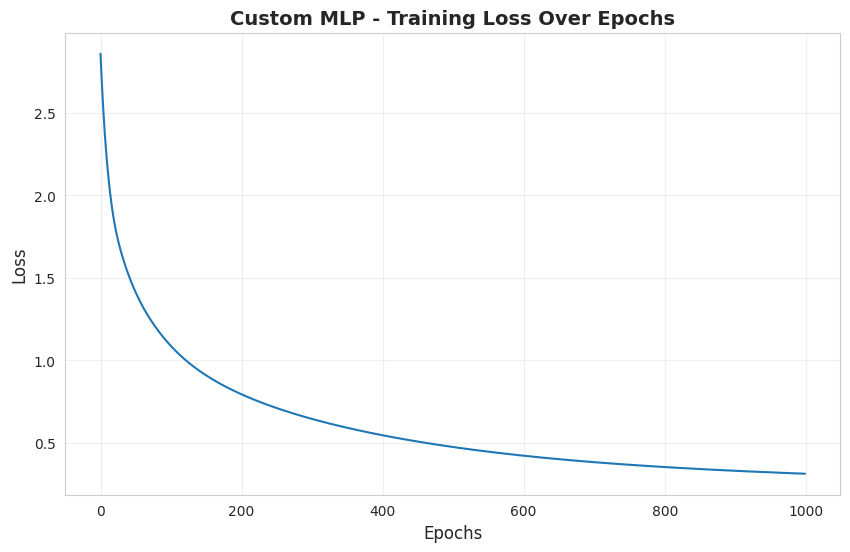

In [10]:
print("\n" + "="*70)
print("CUSTOM MLP TRAINING")
print("="*70)

layer_sizes = [16, 32, 16, 7]
mlp_custom = MLPFromScratch(
    layer_sizes=layer_sizes,
    learning_rate=0.01,
    epochs=1000,
    activation='relu',
    output_activation='softmax'
)

mlp_custom.fit(X_train_scaled, y_train)

plt.figure(figsize=(10, 6))
plt.plot(mlp_custom.loss_history)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Custom MLP - Training Loss Over Epochs', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()


CUSTOM MLP PERFORMANCE

Test Accuracy: 0.9053 (90.53%)

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.97      0.85      0.91       265
      BOMBAY       1.00      0.98      0.99       104
        CALI       0.90      0.95      0.93       326
    DERMASON       0.89      0.92      0.91       709
       HOROZ       0.92      0.96      0.94       386
       SEKER       0.93      0.93      0.93       406
        SIRA       0.84      0.81      0.82       527

    accuracy                           0.91      2723
   macro avg       0.92      0.91      0.92      2723
weighted avg       0.91      0.91      0.90      2723



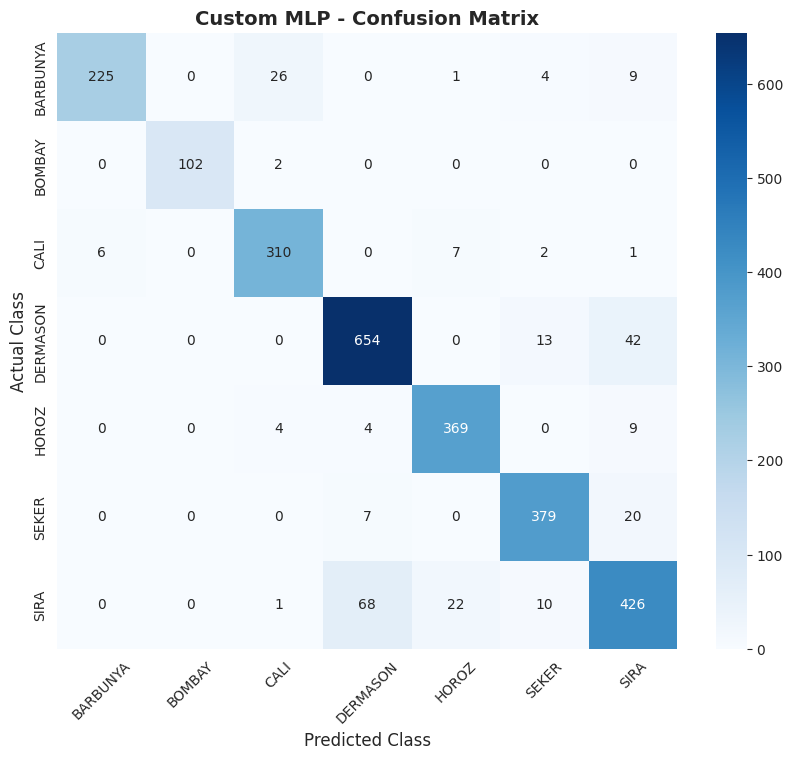

In [11]:
y_pred_custom = mlp_custom.predict(X_test_scaled)
accuracy_custom = accuracy_score(y_test, y_pred_custom)

print("\n" + "="*70)
print("CUSTOM MLP PERFORMANCE")
print("="*70)
print(f"\nTest Accuracy: {accuracy_custom:.4f} ({accuracy_custom*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_custom, target_names=class_names))

cm_custom = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Custom MLP - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('Actual Class', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [12]:
print("\n" + "="*70)
print("SCIKIT-LEARN MLP TRAINING")
print("="*70)

architectures = [
    (10, 'Single hidden layer: 10 neurons'),
    (50, 'Single hidden layer: 50 neurons'),
    (100, 'Single hidden layer: 100 neurons'),
    (10, 10, 'Two hidden layers: 10-10'),
    (50, 20, 'Two hidden layers: 50-20'),
    (100, 50, 'Two hidden layers: 100-50'),
    (10, 10, 10, 'Three hidden layers: 10-10-10'),
    (20, 15, 10, 'Three hidden layers: 20-15-10'),
]

results = []

for i, arch in enumerate(architectures):
    if isinstance(arch[0], tuple):
        hidden_layers = arch[:-1]
        arch_name = arch[-1]
    else:
        hidden_layers = arch[:-1]
        arch_name = arch[-1]

    print(f"\nTesting: {arch_name}")

    mlp_sklearn = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size='auto',
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        verbose=False
    )

    mlp_sklearn.fit(X_train_scaled, y_train)
    y_pred_sklearn = mlp_sklearn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred_sklearn)

    results.append({
        'architecture': arch_name,
        'hidden_layers': hidden_layers,
        'accuracy': accuracy,
        'model': mlp_sklearn
    })

    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

best = max(results, key=lambda x: x['accuracy'])
print(f"\nBest Architecture: {best['architecture']}")
print(f"Best Accuracy: {best['accuracy']:.4f} ({best['accuracy']*100:.2f}%)")


SCIKIT-LEARN MLP TRAINING

Testing: Single hidden layer: 10 neurons
  Accuracy: 0.9218 (92.18%)

Testing: Single hidden layer: 50 neurons
  Accuracy: 0.9254 (92.54%)

Testing: Single hidden layer: 100 neurons
  Accuracy: 0.9247 (92.47%)

Testing: Two hidden layers: 10-10
  Accuracy: 0.9229 (92.29%)

Testing: Two hidden layers: 50-20
  Accuracy: 0.9243 (92.43%)

Testing: Two hidden layers: 100-50
  Accuracy: 0.9277 (92.77%)

Testing: Three hidden layers: 10-10-10
  Accuracy: 0.9199 (91.99%)

Testing: Three hidden layers: 20-15-10
  Accuracy: 0.9266 (92.66%)

Best Architecture: Two hidden layers: 100-50
Best Accuracy: 0.9277 (92.77%)



BEST PERFORMING MLP - DETAILED EVALUATION

Architecture: Two hidden layers: 100-50
Accuracy: 0.9277 (92.77%)

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.91      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.94      0.94      0.94       326
    DERMASON       0.93      0.92      0.92       709
       HOROZ       0.96      0.96      0.96       386
       SEKER       0.94      0.96      0.95       406
        SIRA       0.87      0.88      0.88       527

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



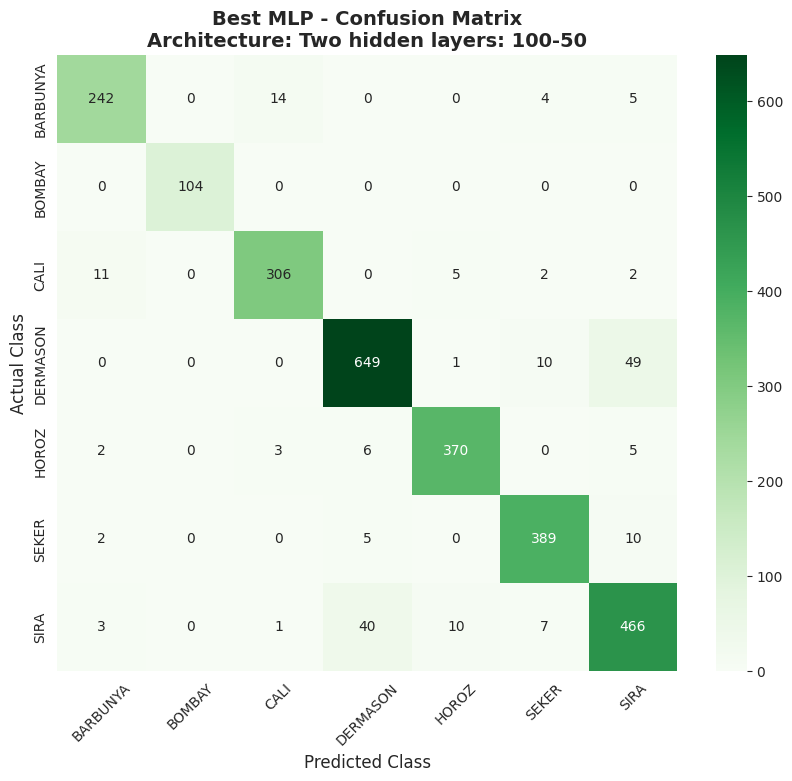


Best model saved to: /content/drive/MyDrive/MLP_DryBean_Project/best_mlp_model.pkl


In [13]:
best_model = best['model']
y_pred_best = best_model.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)

print("\n" + "="*70)
print("BEST PERFORMING MLP - DETAILED EVALUATION")
print("="*70)

print(f"\nArchitecture: {best['architecture']}")
print(f"Accuracy: {accuracy_best:.4f} ({accuracy_best*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=class_names))

cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Best MLP - Confusion Matrix\nArchitecture: {best["architecture"]}',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('Actual Class', fontsize=12)
plt.xticks(rotation=45)
plt.show()

import joblib
joblib.dump(best_model, f'{project_path}/best_mlp_model.pkl')
print(f"\nBest model saved to: {project_path}/best_mlp_model.pkl")


FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features:
         Feature  Importance
10     roundness    0.194427
12  ShapeFactor1    0.163747
15  ShapeFactor4    0.161255
4   AspectRation    0.145262
11   Compactness    0.140818
6     ConvexArea    0.138846
5   Eccentricity    0.138650
0           Area    0.138050
9       Solidity    0.132525
8         Extent    0.131864


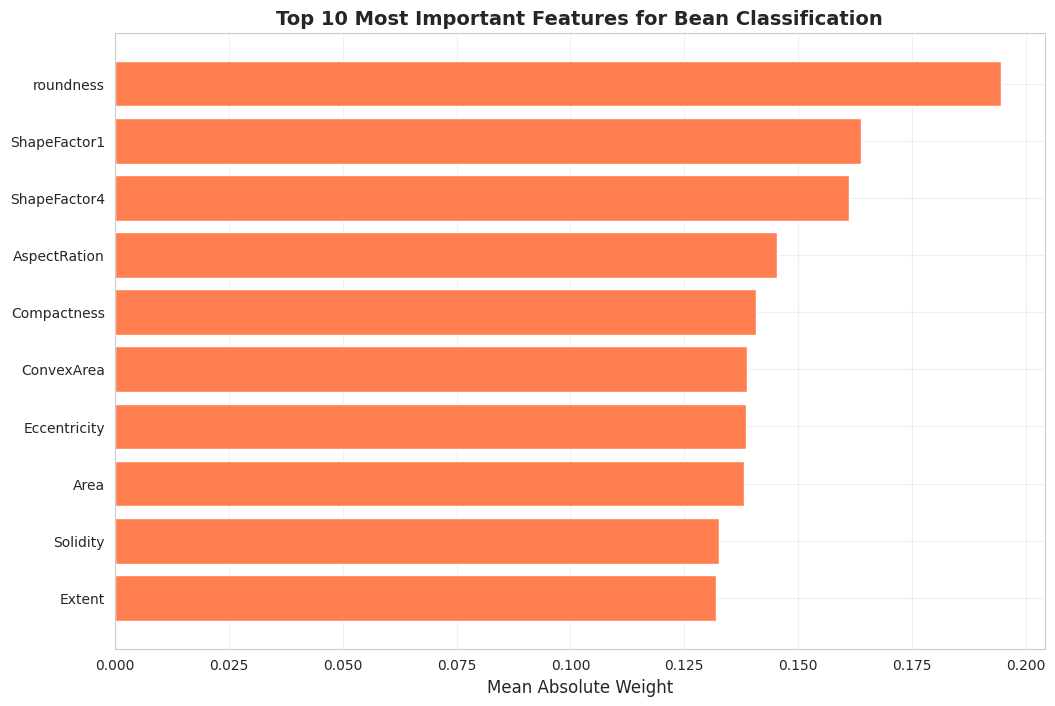

In [14]:
if hasattr(best_model, 'coefs_'):
    feature_importance = np.mean(np.abs(best_model.coefs_[0]), axis=1)
    feature_names = X.columns

    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)

print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)
print("\nTop 10 Most Important Features:")
print(feature_importance_df.head(10))

plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df.head(10)['Feature'],
         feature_importance_df.head(10)['Importance'],
         color='coral')
plt.xlabel('Mean Absolute Weight', fontsize=12)
plt.title('Top 10 Most Important Features for Bean Classification',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()

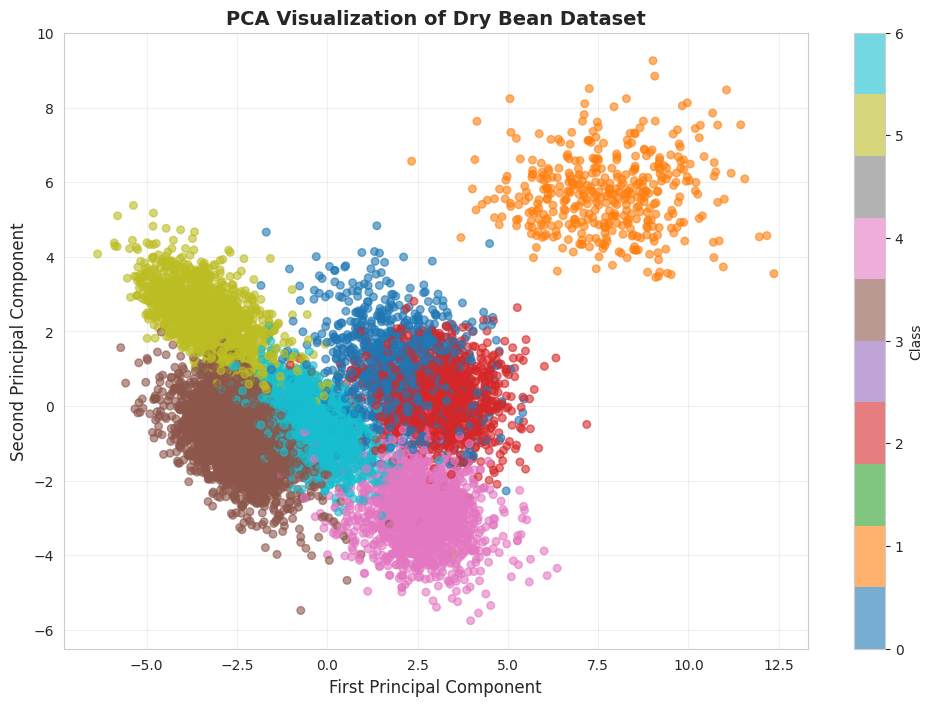


Explained Variance Ratio:
  PC1: 0.5545
  PC2: 0.2646
  Total: 0.8192


In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(12, 8))

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=y_train, cmap='tab10', alpha=0.6, s=30)
plt.colorbar(scatter, label='Class')
plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.title('PCA Visualization of Dry Bean Dataset',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nExplained Variance Ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.4f}")


MODEL COMPARISON RESULTS

Accuracy Comparison:
                    architecture  accuracy
       Two hidden layers: 100-50  0.927653
   Three hidden layers: 20-15-10  0.926552
 Single hidden layer: 50 neurons  0.925450
Single hidden layer: 100 neurons  0.924715
        Two hidden layers: 50-20  0.924348
        Two hidden layers: 10-10  0.922879
 Single hidden layer: 10 neurons  0.921777
   Three hidden layers: 10-10-10  0.919941


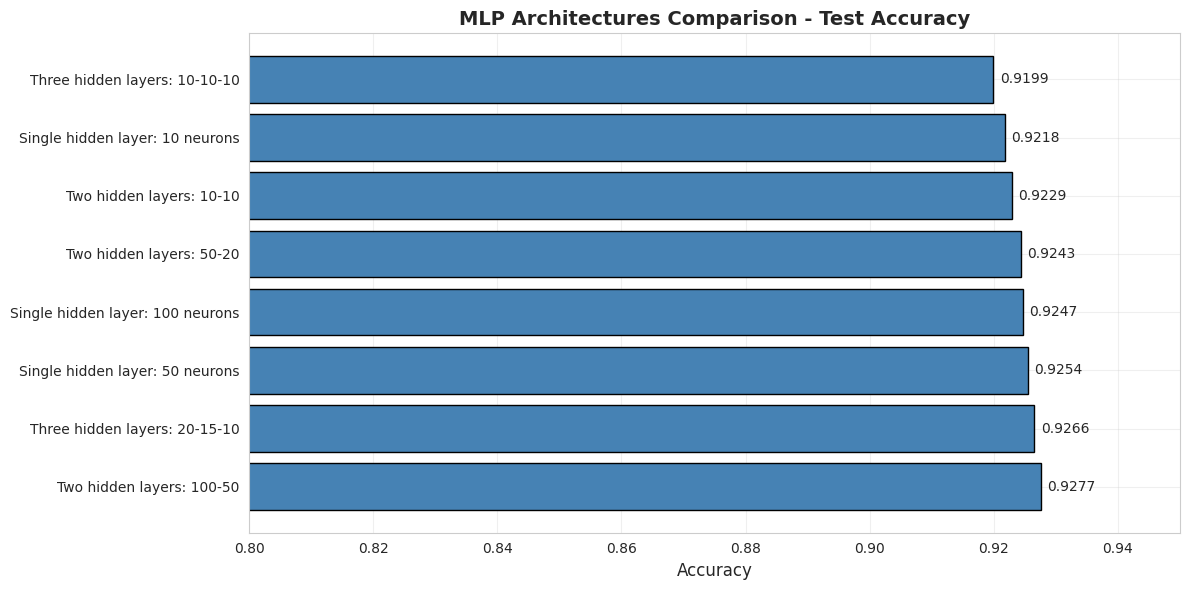

In [16]:
print("\n" + "="*70)
print("MODEL COMPARISON RESULTS")
print("="*70)

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('accuracy', ascending=False)

print("\nAccuracy Comparison:")
print(comparison_df[['architecture', 'accuracy']].to_string(index=False))

plt.figure(figsize=(12, 6))
bars = plt.barh(comparison_df['architecture'], comparison_df['accuracy'],
                color='steelblue', edgecolor='black')
plt.xlabel('Accuracy', fontsize=12)
plt.title('MLP Architectures Comparison - Test Accuracy',
          fontsize=14, fontweight='bold')
plt.xlim(0.8, 0.95)
plt.grid(True, alpha=0.3)

for bar, acc in zip(bars, comparison_df['accuracy']):
    plt.text(acc + 0.001, bar.get_y() + bar.get_height()/2,
             f'{acc:.4f}', va='center')

plt.tight_layout()
plt.show()

In [17]:
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)

print("\nDATASET INFORMATION:")
print(f"  Dataset: Dry Bean Classification")
print(f"  Total Samples: {len(data)}")
print(f"  Features: {len(X.columns)}")
print(f"  Classes: {len(class_names)}")
print(f"  Class Names: {', '.join(class_names)}")

print(f"\nMODEL PERFORMANCE:")
print(f"  Best Model Architecture: {best['architecture']}")
print(f"  Best Test Accuracy: {best['accuracy']:.4f} ({best['accuracy']*100:.2f}%)")

print(f"\nCUSTOM MLP PERFORMANCE:")
print(f"  Architecture: {' -> '.join(map(str, layer_sizes))}")
print(f"  Test Accuracy: {accuracy_custom:.4f} ({accuracy_custom*100:.2f}%)")

print(f"\nTRAINING PARAMETERS:")
print(f"  Training samples: {X_train.shape[0]}")
print(f"  Testing samples: {X_test.shape[0]}")
print(f"  Features scaled: StandardScaler")
print(f"  Labels encoded: LabelEncoder")

print("\nSAVED FILES IN GOOGLE DRIVE:")
print(f"  {project_path}/Dry_Bean_Dataset.xlsx (Dataset)")
print(f"  {project_path}/scaler.pkl (StandardScaler)")
print(f"  {project_path}/label_encoder.pkl (LabelEncoder)")
print(f"  {project_path}/best_mlp_model.pkl (Best MLP Model)")

print("\nProject completed successfully.")


FINAL RESULTS SUMMARY

DATASET INFORMATION:
  Dataset: Dry Bean Classification
  Total Samples: 13611
  Features: 16
  Classes: 7
  Class Names: BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ, SEKER, SIRA

MODEL PERFORMANCE:
  Best Model Architecture: Two hidden layers: 100-50
  Best Test Accuracy: 0.9277 (92.77%)

CUSTOM MLP PERFORMANCE:
  Architecture: 16 -> 32 -> 16 -> 7
  Test Accuracy: 0.9053 (90.53%)

TRAINING PARAMETERS:
  Training samples: 10888
  Testing samples: 2723
  Features scaled: StandardScaler
  Labels encoded: LabelEncoder

SAVED FILES IN GOOGLE DRIVE:
  /content/drive/MyDrive/MLP_DryBean_Project/Dry_Bean_Dataset.xlsx (Dataset)
  /content/drive/MyDrive/MLP_DryBean_Project/scaler.pkl (StandardScaler)
  /content/drive/MyDrive/MLP_DryBean_Project/label_encoder.pkl (LabelEncoder)
  /content/drive/MyDrive/MLP_DryBean_Project/best_mlp_model.pkl (Best MLP Model)

Project completed successfully.


In [18]:
def predict_bean_class(features, model, scaler, encoder):
    features_array = np.array(features).reshape(1, -1)
    features_scaled = scaler.transform(features_array)
    prediction = model.predict(features_scaled)
    class_name = encoder.inverse_transform(prediction)[0]
    return class_name

print("\n" + "="*70)
print("PREDICTION DEMO")
print("="*70)

avg_features = X.mean().values
print("\nTesting with average feature values:")
predicted_class = predict_bean_class(avg_features, best_model, scaler, le)
print(f"  Predicted Class: {predicted_class}")

random_sample = X.sample(1).values.flatten()
print(f"\nTesting with random sample from dataset:")
predicted_class = predict_bean_class(random_sample, best_model, scaler, le)
print(f"  Feature values: {random_sample[:5]}...")
print(f"  Predicted Class: {predicted_class}")


PREDICTION DEMO

Testing with average feature values:
  Predicted Class: SIRA

Testing with random sample from dataset:
  Feature values: [3.30060000e+04 6.69769000e+02 2.23527749e+02 1.88242941e+02
 1.18744293e+00]...
  Predicted Class: SEKER
